In [21]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib

problem_name = 'qf'
model_name = 'rf'
sheet_names = ['qf_15','qf_17', 'qf_21', 'qf_26', 'qf_31', 'qf_36']

all_results = []

for sheet_name in sheet_names:
    kl_data = pd.read_excel('20240607FULL_final.xlsx', index_col=0, sheet_name=sheet_name)
    
    X = kl_data.iloc[:, :-2]
    y = kl_data['屈服强度']
    
    bins = np.linspace(y.min(), y.max(), 11)
    y_binned = np.digitize(y, bins)
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)
    
    r2_scores = []
    mape_scores = []
    mae_scores = []
    
    results = []
    
    index = 0
    for train_index, test_index in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        model = RandomForestRegressor(random_state=60)
        model.fit(X_train, y_train)
    
        model_save_path = f'final_model/{problem_name}/{model_name}/{sheet_name}'
        if not os.path.exists(model_save_path):
            os.makedirs(model_save_path)
        joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')
        
        y_pred = model.predict(X_test)
    
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)
        mae_scores.append(mae)
        mape_scores.append(mape)
        
        results.append({
            'Sheet Name': sheet_name,
            'Fold': index + 1,
            'MAE': mae,
            'MAPE': mape,
            'R2': r2
        })
        
        index += 1
    
    mean_r2 = np.mean(r2_scores)
    mean_mae = np.mean(mae_scores)
    mean_mape = np.mean(mape_scores)
    
    results.append({
        'Sheet Name': sheet_name,
        'Fold': 'Mean',
        'MAE': mean_mae,
        'MAPE': mean_mape,
        'R2': mean_r2
    })
    
    all_results.extend(results)

all_results_df = pd.DataFrame(all_results)
all_results_df.to_excel(f'final_model/{problem_name}/{model_name}_cross_validation_results_all_sheets.xlsx', index=False)

print("Cross-validation results saved for all sheet names.")


F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
F:\Anaconda\envs\new_env\lib\s

Cross-validation results saved for all sheet names.


In [7]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib

problem_name = 'kl'
model_name = 'rf'
sheet_names = ['kl_15', 'kl_17','kl_21', 'kl_26', 'kl_31', 'kl_36']

all_results = []

for sheet_name in sheet_names:
    kl_data = pd.read_excel('20240607FULL_final.xlsx', sheet_name=sheet_name)
    
    X = kl_data.iloc[:, :-2]
    y = kl_data['抗拉强度 （UTS）']
    
    bins = np.linspace(y.min(), y.max(), 11)
    y_binned = np.digitize(y, bins)
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)
    
    r2_scores = []
    mape_scores = []
    mae_scores = []
    
    results = []
    
    index = 0
    for train_index, test_index in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        model = RandomForestRegressor(random_state=60)
        model.fit(X_train, y_train)
    
        model_save_path = f'final_model/{problem_name}/{model_name}/{sheet_name}'
        if not os.path.exists(model_save_path):
            os.makedirs(model_save_path)
        joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')
        
        y_pred = model.predict(X_test)
    
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)
        mae_scores.append(mae)
        mape_scores.append(mape)
        
        results.append({
            'Sheet Name': sheet_name,
            'Fold': index + 1,
            'MAE': mae,
            'MAPE': mape,
            'R2': r2
        })
        
        index += 1
    
    mean_r2 = np.mean(r2_scores)
    mean_mae = np.mean(mae_scores)
    mean_mape = np.mean(mape_scores)
    
    results.append({
        'Sheet Name': sheet_name,
        'Fold': 'Mean',
        'MAE': mean_mae,
        'MAPE': mean_mape,
        'R2': mean_r2
    })
    
    all_results.extend(results)

all_results_df = pd.DataFrame(all_results)
all_results_df.to_excel(f'final_model/{problem_name}/{model_name}_cross_validation_results_all_sheets.xlsx', index=False)

print("Cross-validation results saved for all sheet names.")


The least populated class in y has only 2 members, which is less than n_splits=5.
The least populated class in y has only 2 members, which is less than n_splits=5.
The least populated class in y has only 2 members, which is less than n_splits=5.
The least populated class in y has only 2 members, which is less than n_splits=5.
The least populated class in y has only 2 members, which is less than n_splits=5.
The least populated class in y has only 2 members, which is less than n_splits=5.


Cross-validation results saved for all sheet names.


In [6]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook

problem_name = 'qf'
model_name = 'rf'
sheet_name = 'qf_21'
data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'

# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
print(X.columns)
y = kl_data['屈服强度']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 结果存储
r2_scores = []
mape_scores = []
mae_scores = []
results = []
overall_shap_df = pd.DataFrame()
feature_shap_dfs = {feature: pd.DataFrame(columns=['Model', 'Fold', 'Original Value', 'SHAP Value']) for feature in X.columns}

# 模型训练和评估
index = 0
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(random_state=60)
    model.fit(X_train, y_train)

    joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')
    print('模型已保存')
    
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)
    
    results.append({
        'Fold': index + 1,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    })
    
#     # SHAP分析
#     explainer = shap.TreeExplainer(model)
#     shap_values = explainer.shap_values(X_train)
#     shap.initjs()
# 
#     # 测试数据与SHAP值DataFrame
#     df0 = pd.DataFrame(np.array(X_train), columns=X_train.columns)
#     df_shap_values = pd.DataFrame(np.array(shap_values), columns=X_train.columns)
# 
#     # 保存每个特征的SHAP值
#     for feature in X.columns:
#         feature_shap_df = feature_shap_dfs[feature]
#         temp_df = pd.DataFrame({
#             'Model': [model_name] * len(X_train),
#             'Fold': [index + 1] * len(X_train),
#             'Original Value': X_train[feature].values,
#             'SHAP Value': shap_values[:, X.columns.get_loc(feature)]
#         })
#         feature_shap_dfs[feature] = pd.concat([feature_shap_df, temp_df])
#         
#         # 更新 overall_shap_df
#         temp_shap_importance_df = pd.DataFrame({
#             'Feature Name': [feature] * len(X_train),
#             'SHAP Value': shap_values[:, X.columns.get_loc(feature)],
#             'Model': [f'{model_name}_{index + 1}'] * len(X_train)
#         })
#         overall_shap_df = pd.concat([overall_shap_df, temp_shap_importance_df])
# 
    index += 1
# 
# # 计算平均SHAP值
# overall_shap_importance = overall_shap_df.groupby('Feature Name')['SHAP Value'].mean().reset_index().sort_values(by='SHAP Value', ascending=False)
# 
# # 保存综合的SHAP特征重要性
# with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
#     overall_shap_importance.to_excel(writer, sheet_name=f'{problem_name}_{model_name}_overall_shap_importance', index=False)
# 
# # 保存每个特征的SHAP值到新的Excel文件
# feature_shap_output_path = f'final_model/{problem_name}/{model_name}_feature_shap_values.xlsx'
# with pd.ExcelWriter(feature_shap_output_path, engine='openpyxl') as writer:
#     for feature, feature_shap_df in feature_shap_dfs.items():
#         feature_shap_df.to_excel(writer, sheet_name=feature, index=False)

# 保存交叉验证结果
mean_r2 = np.mean(r2_scores)
mean_mae = np.mean(mae_scores)
mean_mape = np.mean(mape_scores)

results.append({
    'Fold': 'Mean',
    'MAE': mean_mae,
    'MAPE': mean_mape,
    'R2': mean_r2
})

results_df = pd.DataFrame(results)
results_df.to_excel(f'{model_save_path}/{model_name}_{sheet_name}_cross_validation_results.xlsx', index=False)

print(f'sheet_name:{sheet_name}')
print(f"Mean Absolute Percentage Error: {mean_mape}")
print(f"Mean Absolute Error: {mean_mae}")
print(f"R^2 Score: {mean_r2}")

print("SHAP importance results saved successfully!")


Index(['MagpieData avg_dev MeltingT', 'Length of prismatic phase',
       'mean AtomicRadius', 'Zr fraction', 'Fraction of prismatic phase',
       'Width of prismatic phase', 'frac f valence electrons',
       'Diameter of prismatic phase', 'Diameter of basal phase',
       'Width of basal phase', 'Calculated Grain Boundary',
       'Interant electrons', 'Calculated Yield Strength',
       'Length of Basal phase', 'Habit Plane', 'Fraction of basal phase',
       'Yang omega', 'Distribution of precipitation', 'Grain Size'],
      dtype='object')
模型已保存
模型已保存


The least populated class in y has only 2 members, which is less than n_splits=5.


模型已保存
模型已保存
模型已保存
sheet_name:qf_21
Mean Absolute Percentage Error: 0.13454973832033157
Mean Absolute Error: 32.781527272727274
R^2 Score: 0.8536245835907461
SHAP importance results saved successfully!


F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Mean Absolute Percentage Error: 0.10411832585723457
Mean Absolute Error: 34.34658181818182
R^2 Score: 0.7935124491498967


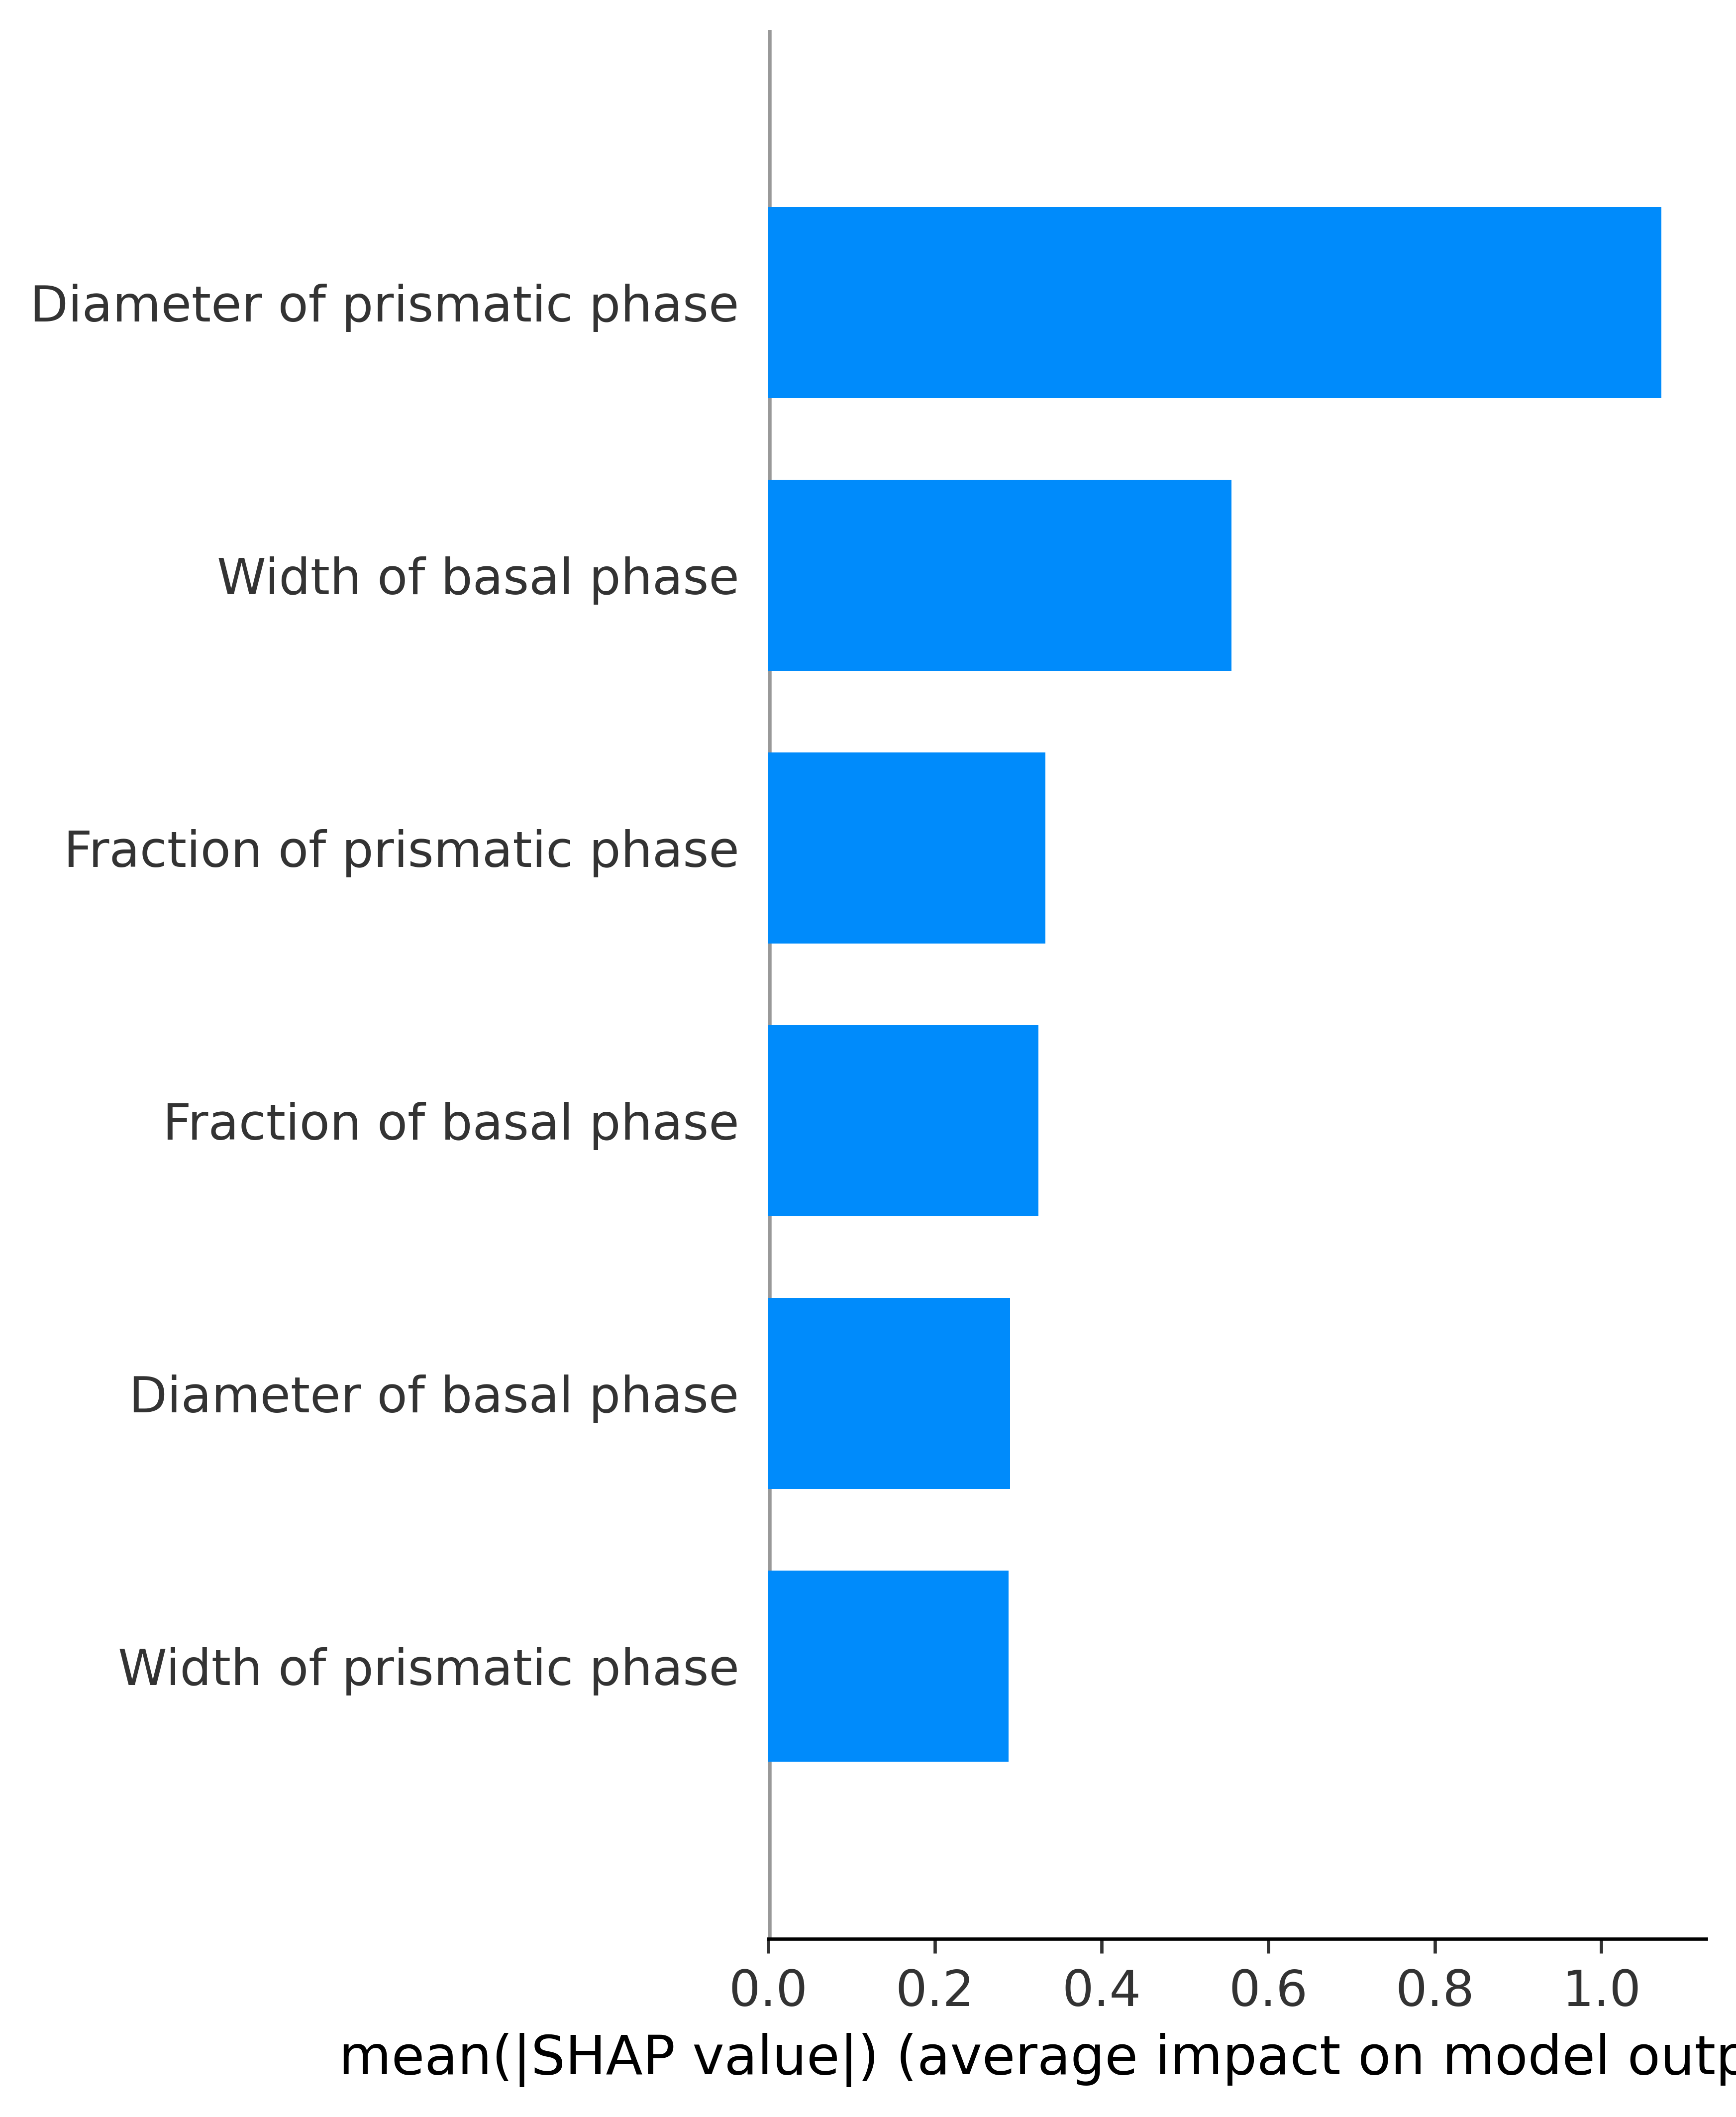

SHAP importance results saved successfully!


In [6]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook
import matplotlib.pyplot as plt

problem_name = 'kl'
model_name = 'rf'
sheet_name = 'kl_21'
data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'
selected_features = ['Diameter of basal phase',
                               'Width of basal phase', 'Fraction of basal phase', 'Diameter of prismatic phase', 'Width of prismatic phase',
                               'Fraction of prismatic phase']  # 你希望绘制 SHAP summary plot 的特征列表

# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, index_col=0, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
y = kl_data['抗拉强度 （UTS）']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 结果存储
r2_scores = []
mape_scores = []
mae_scores = []
results = []
overall_shap_df = pd.DataFrame()
index = 0

# 模型训练和评估
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(random_state=60)
    model.fit(X_train, y_train)

    joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')
    
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)
    
    results.append({
        'Fold': index + 1,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    })
    
    # SHAP分析
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap.initjs()

    # 测试数据与SHAP值DataFrame
    df_shap_values = pd.DataFrame(shap_values, columns=X_test.columns)
    
    # 保存 SHAP 值
    for feature in selected_features:
        temp_shap_df = pd.DataFrame({
            'Feature Name': [feature] * len(X_test),
            'SHAP Value': shap_values[:, X_test.columns.get_loc(feature)],
            'Fold': [index + 1] * len(X_test)
        })
        overall_shap_df = pd.concat([overall_shap_df, temp_shap_df])
    
    index += 1

# 计算平均SHAP值
overall_shap_importance = overall_shap_df.groupby('Feature Name')['SHAP Value'].mean().reset_index().sort_values(by='SHAP Value', ascending=False)

# 保存综合的SHAP特征重要性
with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
    overall_shap_importance.to_excel(writer, sheet_name=f'{problem_name}_{model_name}_overall_shap_importance', index=False)

# 保存交叉验证结果
mean_r2 = np.mean(r2_scores)
mean_mae = np.mean(mae_scores)
mean_mape = np.mean(mape_scores)

results.append({
    'Fold': 'Mean',
    'MAE': mean_mae,
    'MAPE': mean_mape,
    'R2': mean_r2,
})

results_df = pd.DataFrame(results)
results_df.to_excel(f'{model_save_path}/{model_name}_{sheet_name}_cross_validation_results.xlsx', index=False)

print(f"Mean Absolute Percentage Error: {mean_mape}")
print(f"Mean Absolute Error: {mean_mae}")
print(f"R^2 Score: {mean_r2}")

# 绘制 SHAP summary plot
shap_values = overall_shap_df.pivot_table(index='Feature Name', columns='Fold', values='SHAP Value')
shap.summary_plot(shap_values.values.T, features=X_test[selected_features], show=False,feature_names=selected_features, plot_type='bar')
plt.gcf().set_dpi(600)  # 设置dpi

plt.gcf().set_size_inches(5, 8)  # 设置图像大小
plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

plt.show()


print("SHAP importance results saved successfully!")



In [2]:
# 抗拉强度的shap计算
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook

problem_name = 'kl'
model_name = 'rf'
sheet_name = 'kl_21'
data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'

# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, index_col=0, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
print(X.columns)
y = kl_data['抗拉强度 （UTS）']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 结果存储
r2_scores = []
mape_scores = []
mae_scores = []
results = []
overall_shap_df = pd.DataFrame()
feature_shap_dfs = {feature: pd.DataFrame(columns=['Model', 'Fold', 'Original Value', 'SHAP Value']) for feature in X.columns}

# 模型训练和评估
index = 0
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(random_state=60)
    model.fit(X_train, y_train)

    joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')
    
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)
    
    results.append({
        'Fold': index + 1,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    })
    
    # SHAP分析
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    shap.initjs()

    # 测试数据与SHAP值DataFrame
    df0 = pd.DataFrame(np.array(X_train), columns=X_train.columns)
    df_shap_values = pd.DataFrame(np.array(shap_values), columns=X_train.columns)

    # 保存每个特征的SHAP值
    for feature in X.columns:
        feature_shap_df = feature_shap_dfs[feature]
        temp_df = pd.DataFrame({
            'Model': [model_name] * len(X_train),
            'Fold': [index + 1] * len(X_train),
            'Original Value': X_train[feature].values,
            'SHAP Value': shap_values[:, X.columns.get_loc(feature)]
        })
        feature_shap_dfs[feature] = pd.concat([feature_shap_df, temp_df])
        
        # 更新 overall_shap_df
        temp_shap_importance_df = pd.DataFrame({
            'Feature Name': [feature] * len(X_train),
            'SHAP Value': shap_values[:, X.columns.get_loc(feature)],
            'Model': [f'{model_name}_{index + 1}'] * len(X_train)
        })
        overall_shap_df = pd.concat([overall_shap_df, temp_shap_importance_df])

    index += 1

# 计算平均SHAP值
overall_shap_importance = overall_shap_df.groupby('Feature Name')['SHAP Value'].mean().reset_index().sort_values(by='SHAP Value', ascending=False)

# 保存综合的SHAP特征重要性
with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
    overall_shap_importance.to_excel(writer, sheet_name=f'{problem_name}_{model_name}_overall_shap_importance', index=False)

# 保存每个特征的SHAP值到新的Excel文件
feature_shap_output_path = f'final_model/{problem_name}/{model_name}_feature_shap_values.xlsx'
with pd.ExcelWriter(feature_shap_output_path, engine='openpyxl') as writer:
    for feature, feature_shap_df in feature_shap_dfs.items():
        feature_shap_df.to_excel(writer, sheet_name=feature, index=False)

# 保存交叉验证结果
mean_r2 = np.mean(r2_scores)
mean_mae = np.mean(mae_scores)
mean_mape = np.mean(mape_scores)

results.append({
    'Fold': 'Mean',
    'MAE': mean_mae,
    'MAPE': mean_mape,
    'R2': mean_r2,
})

results_df = pd.DataFrame(results)
results_df.to_excel(f'{model_save_path}/{model_name}_{sheet_name}_cross_validation_results.xlsx', index=False)

print(f"Mean Absolute Percentage Error: {mean_mape}")
print(f"Mean Absolute Error: {mean_mae}")
print(f"R^2 Score: {mean_r2}")

print("SHAP importance results saved successfully!")

Index(['Length of prismatic phase', 'Zr fraction',
       'Fraction of prismatic phase', 'Width of prismatic phase',
       'Diameter of prismatic phase', 'Diameter of basal phase',
       'Width of basal phase', 'MagpieData range GSvolume_pa',
       'Mixing enthalpy', 'Calculated Grain Boundary',
       'MagpieData mean GSvolume_pa', 'Interant electrons',
       'Calculated Yield Strength', 'Length of Basal phase', 'Habit Plane',
       'Fraction of basal phase', 'Distribution of precipitation',
       'Grain Size'],
      dtype='object')


F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


C:\Users\acer-pc\AppData\Local\Temp\ipykernel_25548\1483005353.py:90: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  feature_shap_dfs[feature] = pd.concat([feature_shap_df, temp_df])


Mean Absolute Percentage Error: 0.10411832585723457
Mean Absolute Error: 34.34658181818182
R^2 Score: 0.7935124491498967
SHAP importance results saved successfully!
